# Section 3 - ANN

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [69]:
df = pd.read_csv('/Users/moyusii/Desktop/winequality-red-1.csv', header=None)

df = df[0].str.split(';', expand=True)
df.columns = df.iloc[0]
df = df.drop(0)
df = df.reset_index(drop=True)

df.columns = df.columns.str.replace('"', '').str.strip()
df = df.apply(pd.to_numeric)

X = df.drop(['quality'], axis=1)
y = df['quality']

print(X.head())
print(y.head())

0  fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

0  free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

0  alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4      9.4  
0    5
1

In [70]:
# Train-test split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

print(X_tr.shape)
print(X_te.shape)

(1071, 11)
(528, 11)


Hidden nodes:   10 | Train Acc: 0.6284 | Test Acc: 0.5909
Hidden nodes:   20 | Train Acc: 0.6228 | Test Acc: 0.5871
Hidden nodes:   50 | Train Acc: 0.6564 | Test Acc: 0.6004
Hidden nodes:  100 | Train Acc: 0.6769 | Test Acc: 0.6231
Hidden nodes:  150 | Train Acc: 0.6760 | Test Acc: 0.6004
Hidden nodes:  200 | Train Acc: 0.6937 | Test Acc: 0.6061


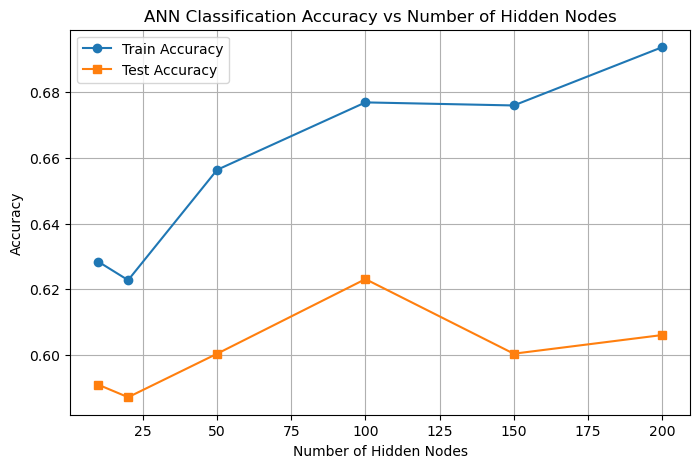


Best number of hidden nodes: 100 — Test Accuracy: 0.6231


In [ ]:
# Hidden node search - find best number of hidden nodes
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

hidden_nodes = [10, 20, 50, 100, 150, 200]
train_accs = []
test_accs = []

for n in hidden_nodes:
    mlp = MLPClassifier(hidden_layer_sizes=(n,), activation='relu', solver='sgd', max_iter=2000, random_state=42)
    mlp.fit(X_tr_scaled, y_tr)
    train_acc = accuracy_score(y_tr, mlp.predict(X_tr_scaled))
    test_acc = accuracy_score(y_te, mlp.predict(X_te_scaled))
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f'Hidden nodes: {n:>4} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}')

# Plot accuracy vs hidden nodes
plt.figure(figsize=(8, 5))
plt.plot(hidden_nodes, train_accs, marker='o', label='Train Accuracy')
plt.plot(hidden_nodes, test_accs, marker='s', label='Test Accuracy')
plt.xlabel('Number of Hidden Nodes')
plt.ylabel('Accuracy')
plt.title('ANN Classification Accuracy vs Number of Hidden Nodes')
plt.legend()
plt.grid(True)
plt.show()

best_n = hidden_nodes[np.argmax(test_accs)]
print(f'\nBest number of hidden nodes: {best_n} — Test Accuracy: {max(test_accs):.4f}')

In [72]:
# Basic ANN model using best hidden node size

ann = MLPClassifier(hidden_layer_sizes=(best_n,), activation='relu', solver='sgd', alpha=0.0001, learning_rate_init=0.001, max_iter=5000, random_state=42)
pipeline = Pipeline([("scaler", StandardScaler()), ("ann", ann)])
pipeline.fit(X_tr, y_tr)

y_pred_train = pipeline.predict(X_tr)
y_pred_test = pipeline.predict(X_te)

train_acc = accuracy_score(y_tr, y_pred_train)
test_acc = accuracy_score(y_te, y_pred_test)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_te, y_pred_test))

print("\nClassification Report:")
print(classification_report(y_te, y_pred_test))

Training Accuracy: 0.676937441643324
Test Accuracy: 0.6231060606060606

Confusion Matrix:
[[  0   0   2   1   0   0]
 [  0   0  16   1   0   0]
 [  0   1 168  56   0   0]
 [  0   1  62 140   8   0]
 [  0   0   2  43  21   0]
 [  0   0   0   4   2   0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        17
           5       0.67      0.75      0.71       225
           6       0.57      0.66      0.61       211
           7       0.68      0.32      0.43        66
           8       0.00      0.00      0.00         6

    accuracy                           0.62       528
   macro avg       0.32      0.29      0.29       528
weighted avg       0.60      0.62      0.60       528



/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [73]:
# Weighted metrics for basic ANN
precision = precision_score(y_te, y_pred_test, average='weighted')
recall = recall_score(y_te, y_pred_test, average='weighted')
f1 = f1_score(y_te, y_pred_test, average='weighted')

print("Weighted Precision:", precision)
print("Weighted Recall:", recall)
print("Weighted F1 Score:", f1)

Weighted Precision: 0.5993960340734534
Weighted Recall: 0.6231060606060606
Weighted F1 Score: 0.6009405640781116


/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


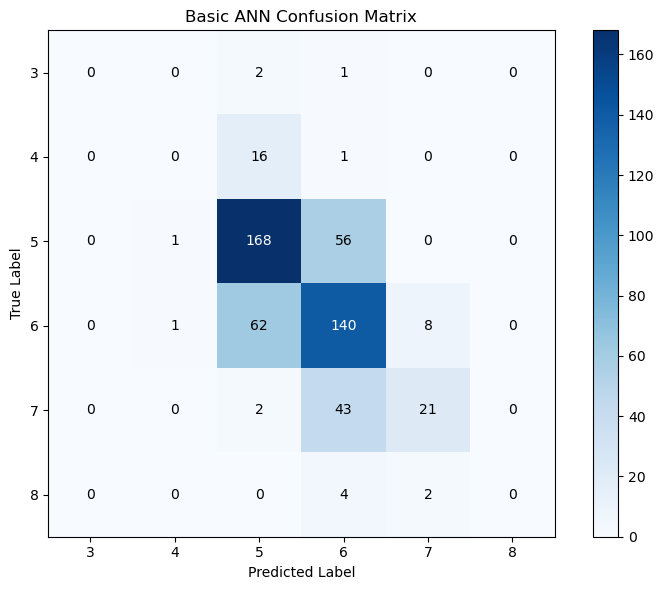

In [74]:
# Confusion matrix heatmap for basic ANN
cm = confusion_matrix(y_te, y_pred_test)
quality_labels = sorted(y.unique())

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(len(quality_labels)), quality_labels)
plt.yticks(range(len(quality_labels)), quality_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Basic ANN Confusion Matrix')

for i in range(len(quality_labels)):
    for j in range(len(quality_labels)):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

In [ ]:
# GridSearchCV to tune hyperparameters

param_grid = {"ann__hidden_layer_sizes": [(10,), (20,), (50,), (20, 10)], "ann__alpha": [0.0001, 0.001, 0.01], "ann__learning_rate_init": [0.001, 0.01], "ann__max_iter": [2000]}

grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring="f1_weighted", cv=5, n_jobs=-1)
grid_search.fit(X_tr, y_tr)

print("Best hyper-parameters:", grid_search.best_params_)
print("Best CV F1 (weighted): {:.3f}".format(grid_search.best_score_))

Best hyper-parameters: {'ann__alpha': 0.001, 'ann__hidden_layer_sizes': (20, 10), 'ann__learning_rate_init': 0.01, 'ann__max_iter': 5000}
Best CV F1 (weighted): 0.585


In [76]:
# Evaluate best tuned ANN
best_ann = grid_search.best_estimator_

best_y_pred_train = best_ann.predict(X_tr)
best_y_pred_test = best_ann.predict(X_te)

best_train_acc = accuracy_score(y_tr, best_y_pred_train)
best_test_acc = accuracy_score(y_te, best_y_pred_test)

print("Best ANN Training Accuracy:", best_train_acc)
print("Best ANN Test Accuracy:", best_test_acc)

print("\nBest ANN Confusion Matrix:")
print(confusion_matrix(y_te, best_y_pred_test))

print("\nBest ANN Classification Report:")
print(classification_report(y_te, best_y_pred_test))

Best ANN Training Accuracy: 0.7889822595704948
Best ANN Test Accuracy: 0.5814393939393939

Best ANN Confusion Matrix:
[[  0   1   1   1   0   0]
 [  0   0  12   5   0   0]
 [  0   0 152  68   4   1]
 [  0   4  64 124  19   0]
 [  0   2   5  28  30   1]
 [  0   0   0   2   3   1]]

Best ANN Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        17
           5       0.65      0.68      0.66       225
           6       0.54      0.59      0.56       211
           7       0.54      0.45      0.49        66
           8       0.33      0.17      0.22         6

    accuracy                           0.58       528
   macro avg       0.34      0.31      0.32       528
weighted avg       0.56      0.58      0.57       528



/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

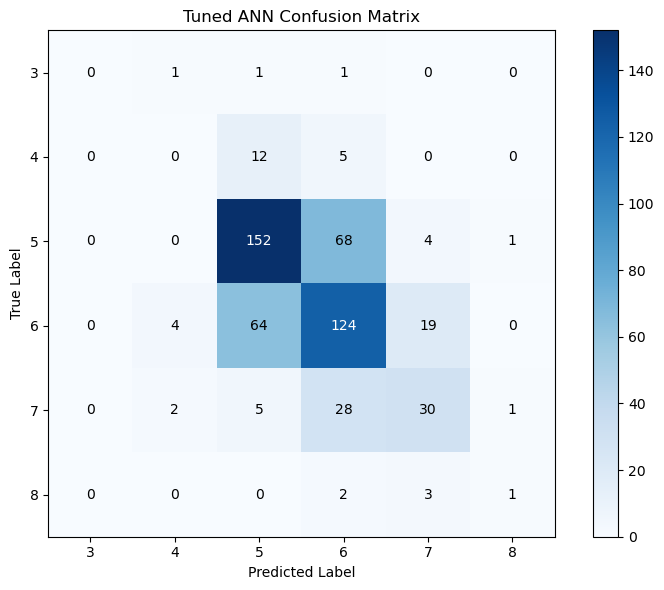

In [77]:
# Confusion matrix heatmap for tuned ANN
cm_best = confusion_matrix(y_te, best_y_pred_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm_best, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(len(quality_labels)), quality_labels)
plt.yticks(range(len(quality_labels)), quality_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Tuned ANN Confusion Matrix')

for i in range(len(quality_labels)):
    for j in range(len(quality_labels)):
        plt.text(j, i, str(cm_best[i, j]), ha='center', va='center',
                 color='white' if cm_best[i, j] > cm_best.max() / 2 else 'black')

plt.tight_layout()
plt.show()

       Model  Training Accuracy  Test Accuracy  Weighted Precision  \
0  Basic ANN           0.676937       0.623106            0.599396   
1  Tuned ANN           0.788982       0.581439            0.564897   

   Weighted Recall  Weighted F1 Score  
0         0.623106           0.600941  
1         0.581439           0.571989  


/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/clean311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


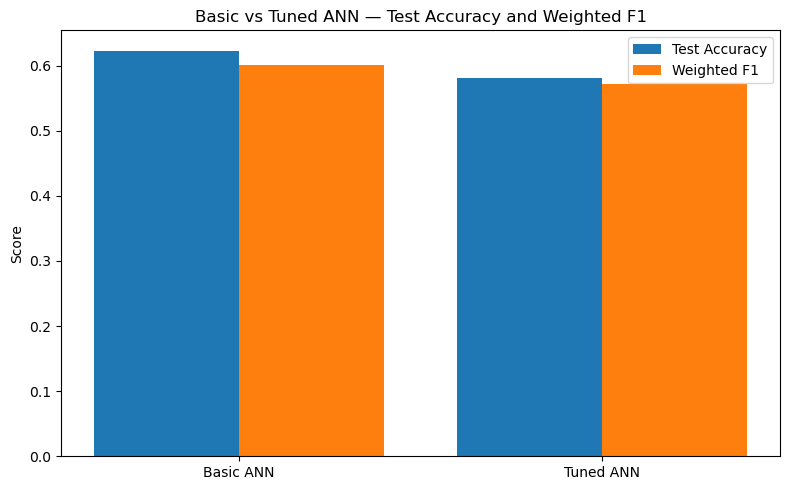

In [78]:
# Results comparison table
results_table = pd.DataFrame({"Model": ["Basic ANN", "Tuned ANN"], "Training Accuracy": [train_acc, best_train_acc], "Test Accuracy": [test_acc, best_test_acc], "Weighted Precision": [precision_score(y_te, y_pred_test, average='weighted'),precision_score(y_te, best_y_pred_test, average='weighted')], "Weighted Recall": [recall_score(y_te, y_pred_test, average='weighted'), recall_score(y_te, best_y_pred_test, average='weighted')], "Weighted F1 Score": [f1_score(y_te, y_pred_test, average='weighted'), f1_score(y_te, best_y_pred_test, average='weighted')]})

print(results_table)

# Bar chart comparison
x = np.arange(len(results_table["Model"]))
plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, results_table["Test Accuracy"], width=0.4, label='Test Accuracy')
plt.bar(x + 0.2, results_table["Weighted F1 Score"], width=0.4, label='Weighted F1')
plt.xticks(x, results_table["Model"])
plt.ylabel('Score')
plt.title('Basic vs Tuned ANN — Test Accuracy and Weighted F1')
plt.legend()
plt.tight_layout()
plt.show()